## Exploratory Data Analysis (EDA)

### Subtask:
Perform initial exploratory data analysis, including checking for missing values, data types, and understanding the distribution of 'spam' and 'ham' messages.


**Reasoning**:
The previous code block successfully downloaded and loaded the dataset. Now, to fulfill the subtask, I will perform exploratory data analysis by checking for missing values, verifying data types, and analyzing the distribution of 'spam' and 'ham' messages, as per the instructions.



In [13]:
print("Checking for missing values:")
print(df.isnull().sum())

print("\nVerifying data types:")
print(df.info())

print("\nAnalyzing the distribution of 'spam' vs. 'ham' messages:")
print(df['label'].value_counts())

# Calculate and print percentage distribution for better understanding
print("\nPercentage distribution of 'spam' vs. 'ham' messages:")
print(df['label'].value_counts(normalize=True) * 100)

Checking for missing values:
label      0
message    0
dtype: int64

Verifying data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Analyzing the distribution of 'spam' vs. 'ham' messages:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage distribution of 'spam' vs. 'ham' messages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


# Task
## Text Preprocessing and Feature Engineering

### Subtask:
Preprocess the `message` column by converting text to lowercase and removing punctuation. Create new numerical features: `message_length` (number of characters) and `word_count` (number of words) for each message in the DataFrame.

## Text Preprocessing and Feature Engineering

### Subtask:
Preprocess the `message` column by converting text to lowercase and removing punctuation. Create new numerical features: `message_length` (number of characters) and `word_count` (number of words) for each message in the DataFrame.


**Reasoning**:
I will preprocess the 'message' column by converting text to lowercase, removing punctuation, and then creating 'message_length' and 'word_count' features as per the subtask instructions. This involves defining a punctuation removal function and applying string operations.



In [14]:
import string

# 1. Convert all messages in the `message` column to lowercase
df['message'] = df['message'].str.lower()

# 2. Define a function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# 3. Apply this punctuation removal function to the `message` column
df['message'] = df['message'].apply(remove_punctuation)

# 4. Create a new column named `message_length`
df['message_length'] = df['message'].str.len()

# 5. Create a new column named `word_count`
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

# 6. Display the first 5 rows of the DataFrame, including the new columns
print("First 5 rows of the DataFrame with new features:")
print(df.head())

print("\nInformation about the updated dataset:")
print(df.info())

First 5 rows of the DataFrame with new features:
  label                                            message  message_length  \
0   ham  go until jurong point crazy available only in ...             102   
1   ham                            ok lar joking wif u oni              23   
2  spam  free entry in 2 a wkly comp to win fa cup fina...             149   
3   ham        u dun say so early hor u c already then say              43   
4   ham  nah i dont think he goes to usf he lives aroun...              59   

   word_count  
0          20  
1           6  
2          28  
3          11  
4          13  

Information about the updated dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           5572 non-null   object
 1   message         5572 non-null   object
 2   message_length  5572 non-null   int64 
 3   word_count     

## Visualize Data Distributions

### Subtask:
Generate visualizations to understand the data better. This includes a bar chart for the distribution of 'spam' vs. 'ham' messages and histograms or kernel density plots to compare message lengths between spam and ham messages.


**Reasoning**:
I need to generate visualizations as per the subtask instructions, which includes a bar chart for message distribution and histograms/KDEs for message length and word count, differentiating between 'spam' and 'ham' messages.



/tmp/ipykernel_561/2407426831.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


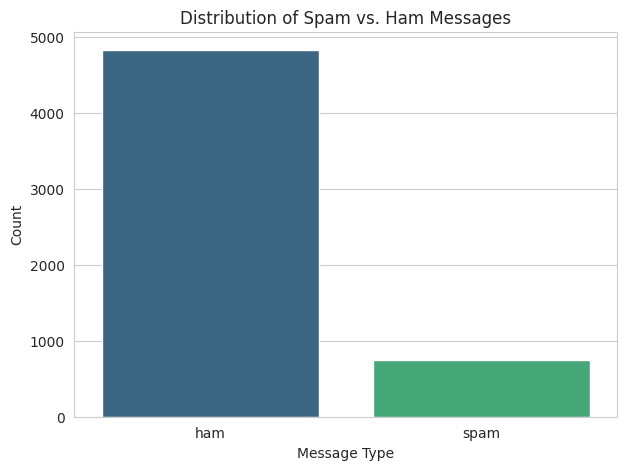

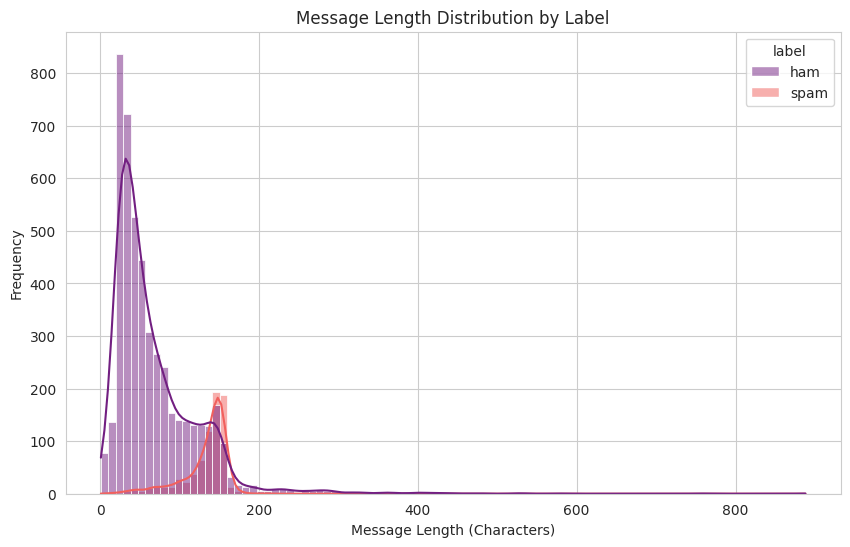

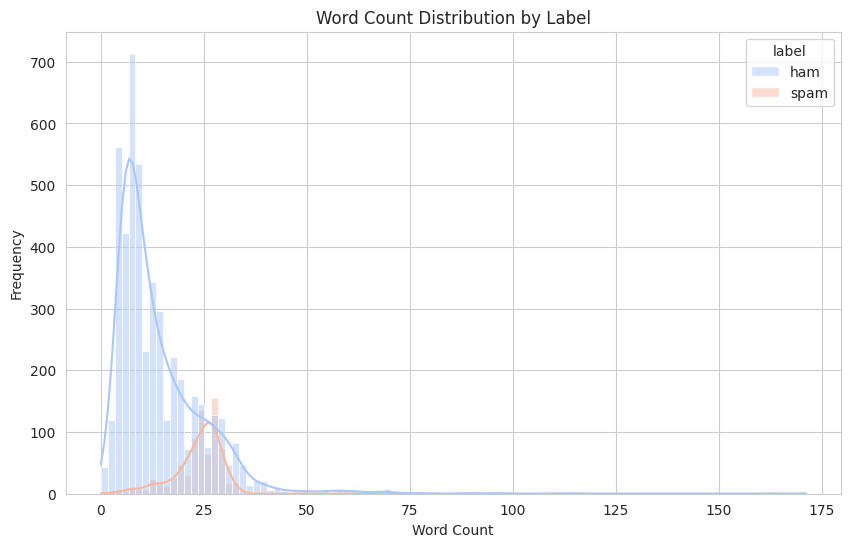

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots for better aesthetics
sns.set_style("whitegrid")

# 1. Bar chart for 'spam' vs. 'ham' distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

# 2. Histogram/KDE for 'message_length' by label
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='message_length', hue='label', kde=True, palette='magma')
plt.title('Message Length Distribution by Label')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# 3. Histogram/KDE for 'word_count' by label
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='label', kde=True, palette='coolwarm')
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without `hue` in `sns.countplot`. I will fix this by explicitly setting `hue='label'` and `legend=False` in `sns.countplot` to align with best practices and remove the warning.



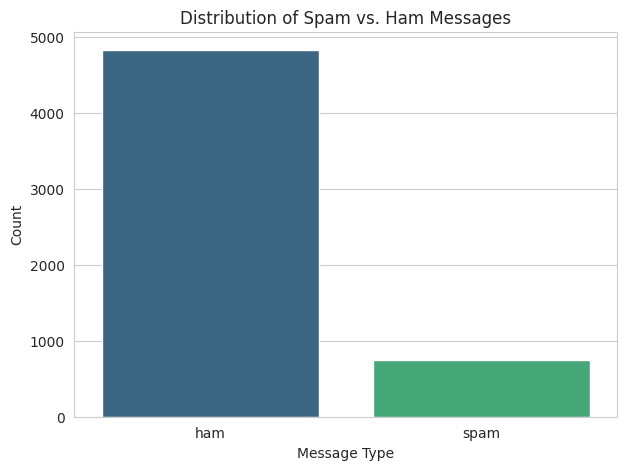

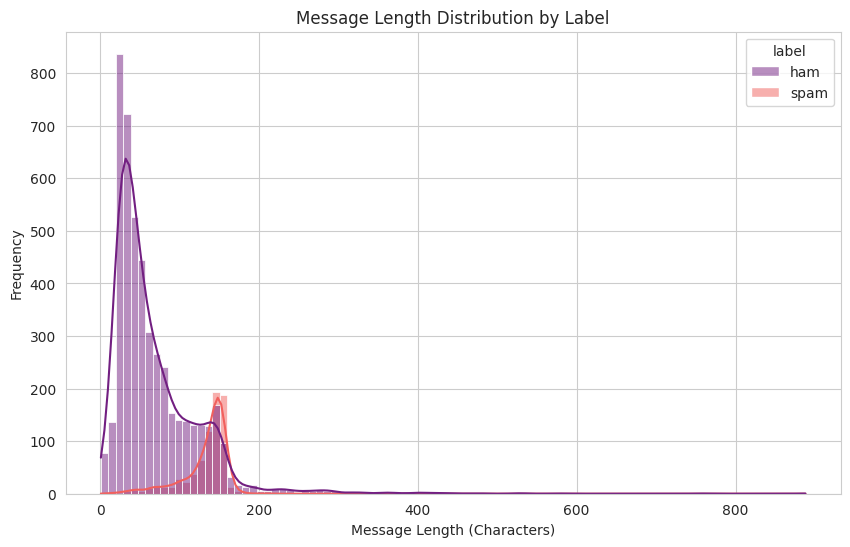

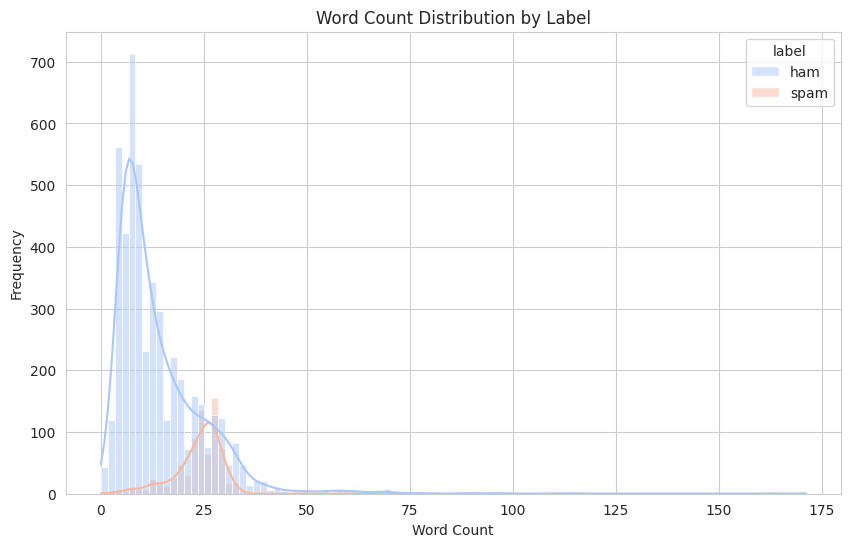

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots for better aesthetics
sns.set_style("whitegrid")

# 1. Bar chart for 'spam' vs. 'ham' distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

# 2. Histogram/KDE for 'message_length' by label
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='message_length', hue='label', kde=True, palette='magma')
plt.title('Message Length Distribution by Label')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# 3. Histogram/KDE for 'word_count' by label
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='label', kde=True, palette='coolwarm')
plt.title('Word Count Distribution by Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## Feature Extraction for Naive Bayes

### Subtask:
Transform the text data into numerical features using a technique like TF-IDF Vectorization or Count Vectorization, which is suitable for the Naive Bayes algorithm.


**Reasoning**:
I will transform the text messages into numerical features using TF-IDF Vectorization and convert the 'label' column into a numerical target variable, as specified by the instructions, which prepares the data for model training.



In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# 2. Apply fit_transform to the 'message' column
X = vectorizer.fit_transform(df['message'])

# 3. Convert the 'label' column into numerical representation (0 for 'ham', 1 for 'spam')
y = df['label'].map({'ham': 0, 'spam': 1})

print("Shape of TF-IDF feature matrix (X):")
print(X.shape)
print("\nShape of numerical target variable (y):")
print(y.shape)
print("\nFirst 5 values of numerical target variable (y):")
print(y.head())

Shape of TF-IDF feature matrix (X):
(5572, 9578)

Shape of numerical target variable (y):
(5572,)

First 5 values of numerical target variable (y):
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


## Train Naive Bayes Model

### Subtask:
Split the preprocessed data into training and testing sets, then train a Naive Bayes classifier on the training data.


**Reasoning**:
I will split the data into training and testing sets using `train_test_split` and then train a `MultinomialNB` classifier on the training data, as instructed.



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Split the data into training and testing sets
# X is the TF-IDF feature matrix, y is the numerical label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# 2. Instantiate a Multinomial Naive Bayes classifier
model = MultinomialNB()

# 3. Train the model using the training data
model.fit(X_train, y_train)

print("\nNaive Bayes model trained successfully.")

Shape of X_train: (4457, 9578)
Shape of X_test: (1115, 9578)
Shape of y_train: (4457,)
Shape of y_test: (1115,)

Naive Bayes model trained successfully.


## Evaluate Model and Visualize Results

### Subtask:
Predict on the test set, calculate and display the accuracy of the Naive Bayes model. Generate a confusion matrix visualization to assess model performance. Also, generate a classification report for more detailed metrics.


**Reasoning**:
I will predict on the test set, calculate accuracy, generate a confusion matrix visualization, and print a classification report to evaluate the Naive Bayes model's performance as per the instructions.



Model Accuracy: 0.9561


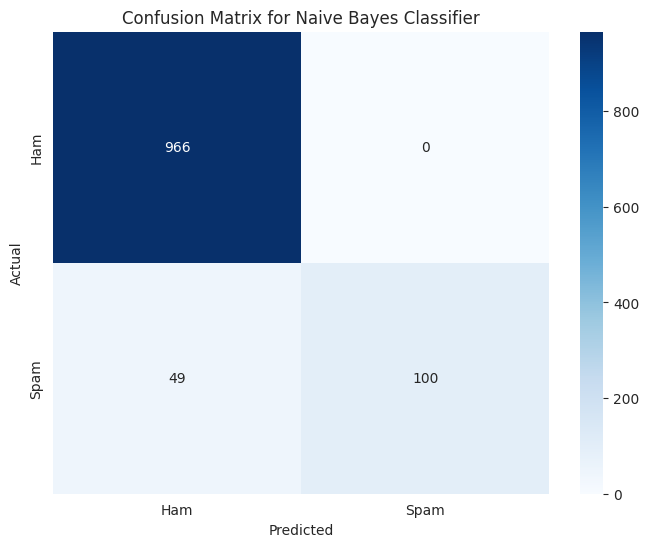


Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.67      0.80       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trained model to make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 2. Calculate and display the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 3. Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# 4. Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

# 5. Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## Final Task

### Subtask:
Summarize the key findings from the EDA, the performance of the Naive Bayes model, and the insights gained from all visualizations.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing and Feature Engineering**: The `message` column was successfully preprocessed by converting text to lowercase and removing punctuation. Two new numerical features, `message_length` and `word_count`, were added to the DataFrame.
*   **Data Distribution**:
    *   The dataset exhibits an imbalanced distribution, with a significantly higher number of 'ham' messages compared to 'spam' messages.
    *   'Spam' messages generally tend to have higher `message_length` and `word_count` compared to 'ham' messages, as observed in the histograms.
*   **Feature Extraction**: Text data was transformed into numerical features using `TfidfVectorizer`, resulting in a feature matrix with 5572 messages and 9578 unique terms. The labels were converted to numerical representations (0 for 'ham', 1 for 'spam').
*   **Naive Bayes Model Performance**:
    *   The trained Multinomial Naive Bayes model achieved an overall accuracy of **95.61%** on the test set.
    *   The confusion matrix revealed that the model correctly classified 966 'ham' messages and 100 'spam' messages. There were 0 false positives (ham classified as spam), but 49 false negatives (spam classified as ham).
    *   The classification report showed excellent precision for 'spam' (1.00), meaning all predicted spam messages were truly spam. However, the recall for 'spam' was lower at 0.67, indicating that the model missed about one-third of the actual spam messages. For 'ham' messages, both precision and recall were very high (0.95 and 1.00 respectively).

### Insights or Next Steps

*   The model demonstrates strong performance in identifying 'ham' messages and has perfect precision in flagging 'spam'. However, improving the recall for 'spam' messages should be a priority to minimize missed spam. This could involve exploring techniques to address class imbalance or using different model architectures.
*   Further analysis could involve investigating the specific characteristics (e.g., common words, message structures) of the 49 spam messages that were misclassified as 'ham' to understand why the model failed to detect them.
